In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [125]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

In [4]:
df = pd.read_csv("income_evaluation.csv")

In [5]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [6]:
df.shape

(32561, 15)

In [7]:
col_names = ['age', 'workclass', 'finalweight', 'education', 'education_num', 'marital_status', 'occupation', 'relationship',
             'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

In [8]:
df.columns = col_names

In [9]:
df.head()

,age,workclass,finalweight,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   finalweight     32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.5 MB


In [11]:
df.isnull().sum()

age               0
workclass         0
finalweight       0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [20]:
categorical = [col for col in df.columns if df[col].dtype == 'str']
numerical = [col for col in df.columns if df[col].dtype != 'str']

In [21]:
categorical

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country',
 'income']

In [22]:
numerical

['age',
 'finalweight',
 'education_num',
 'capital_gain',
 'capital_loss',
 'hours_per_week']

In [23]:
df[categorical].head()

,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,United-States,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States,<=50K
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K


In [24]:
df["workclass"].unique()

<ArrowStringArray>
[       ' State-gov', ' Self-emp-not-inc',          ' Private',
      ' Federal-gov',        ' Local-gov',                ' ?',
     ' Self-emp-inc',      ' Without-pay',     ' Never-worked']
Length: 9, dtype: str

In [25]:
for col in categorical:
    print(df[col].value_counts())

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64
marital_status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64
occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      

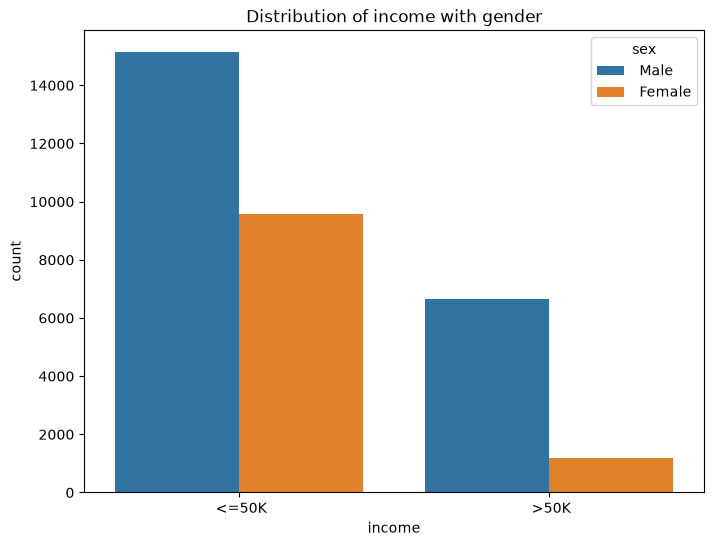

In [27]:
fig,ax = plt.subplots(figsize = (8,6))
ax = sns.countplot(x="income",hue="sex",data = df)
ax.set_title("Distribution of income with gender")
plt.show()

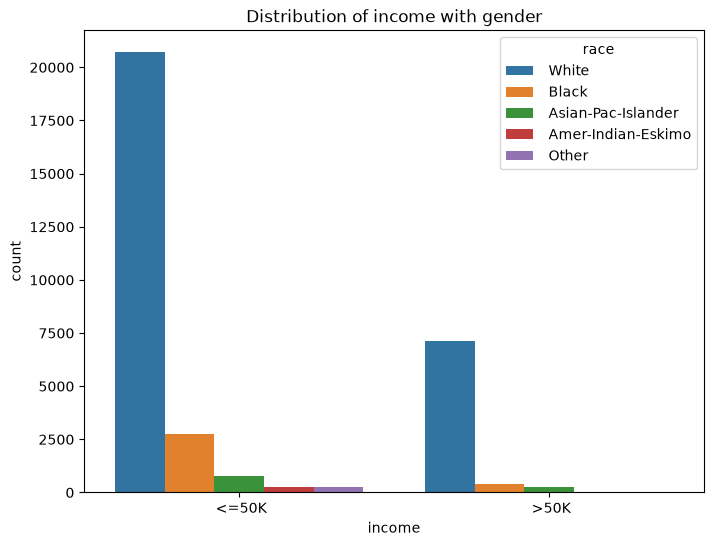

In [28]:
fig,ax = plt.subplots(figsize = (8,6))
ax = sns.countplot(x="income",hue="race",data = df)
ax.set_title("Distribution of income with gender")
plt.show()

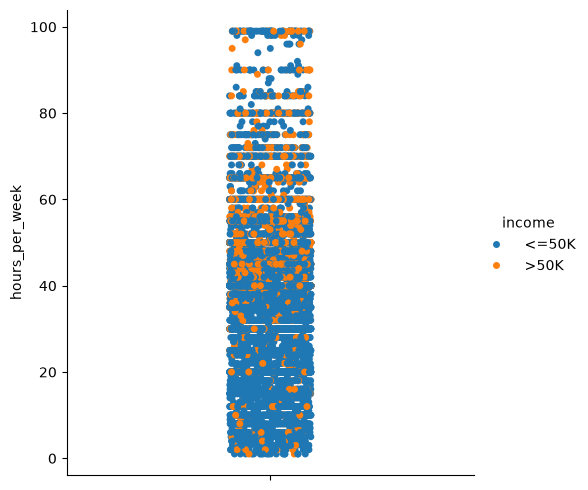

In [31]:
sns.catplot(y=df["hours_per_week"],hue=df["income"])
plt.show()

In [32]:
categorical


['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country',
 'income']

In [33]:
df["workclass"].unique()

<ArrowStringArray>
[       ' State-gov', ' Self-emp-not-inc',          ' Private',
      ' Federal-gov',        ' Local-gov',                ' ?',
     ' Self-emp-inc',      ' Without-pay',     ' Never-worked']
Length: 9, dtype: str

In [37]:
df["workclass"] = df["workclass"].replace(" ?",np.nan)

In [39]:
df["workclass"].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [40]:
df["education"].unique()

<ArrowStringArray>
[   ' Bachelors',      ' HS-grad',         ' 11th',      ' Masters',
          ' 9th', ' Some-college',   ' Assoc-acdm',    ' Assoc-voc',
      ' 7th-8th',    ' Doctorate',  ' Prof-school',      ' 5th-6th',
         ' 10th',      ' 1st-4th',    ' Preschool',         ' 12th']
Length: 16, dtype: str

In [41]:
df["marital_status"].unique()

<ArrowStringArray>
[        ' Never-married',    ' Married-civ-spouse',              ' Divorced',
 ' Married-spouse-absent',             ' Separated',     ' Married-AF-spouse',
               ' Widowed']
Length: 7, dtype: str

In [42]:
df["occupation"].unique()

<ArrowStringArray>
[     ' Adm-clerical',   ' Exec-managerial', ' Handlers-cleaners',
    ' Prof-specialty',     ' Other-service',             ' Sales',
      ' Craft-repair',  ' Transport-moving',   ' Farming-fishing',
 ' Machine-op-inspct',      ' Tech-support',                 ' ?',
   ' Protective-serv',      ' Armed-Forces',   ' Priv-house-serv']
Length: 15, dtype: str

In [43]:
df["occupation"]=df["occupation"].replace(" ?",np.nan)

In [44]:
df["occupation"].value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [45]:
df["native_country"].unique()

<ArrowStringArray>
[             ' United-States',                       ' Cuba',
                    ' Jamaica',                      ' India',
                          ' ?',                     ' Mexico',
                      ' South',                ' Puerto-Rico',
                   ' Honduras',                    ' England',
                     ' Canada',                    ' Germany',
                       ' Iran',                ' Philippines',
                      ' Italy',                     ' Poland',
                   ' Columbia',                   ' Cambodia',
                   ' Thailand',                    ' Ecuador',
                       ' Laos',                     ' Taiwan',
                      ' Haiti',                   ' Portugal',
         ' Dominican-Republic',                ' El-Salvador',
                     ' France',                  ' Guatemala',
                      ' China',                      ' Japan',
                 ' Yugoslavia',     

In [46]:
df["native_country"]=df["native_country"].replace(" ?",np.nan)

In [47]:
df["native_country"].value_counts()

native_country
United-States                 29170
Mexico                          643
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
France                           29
Greece       

In [48]:
df.isnull().sum()

age                  0
workclass         1836
finalweight          0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

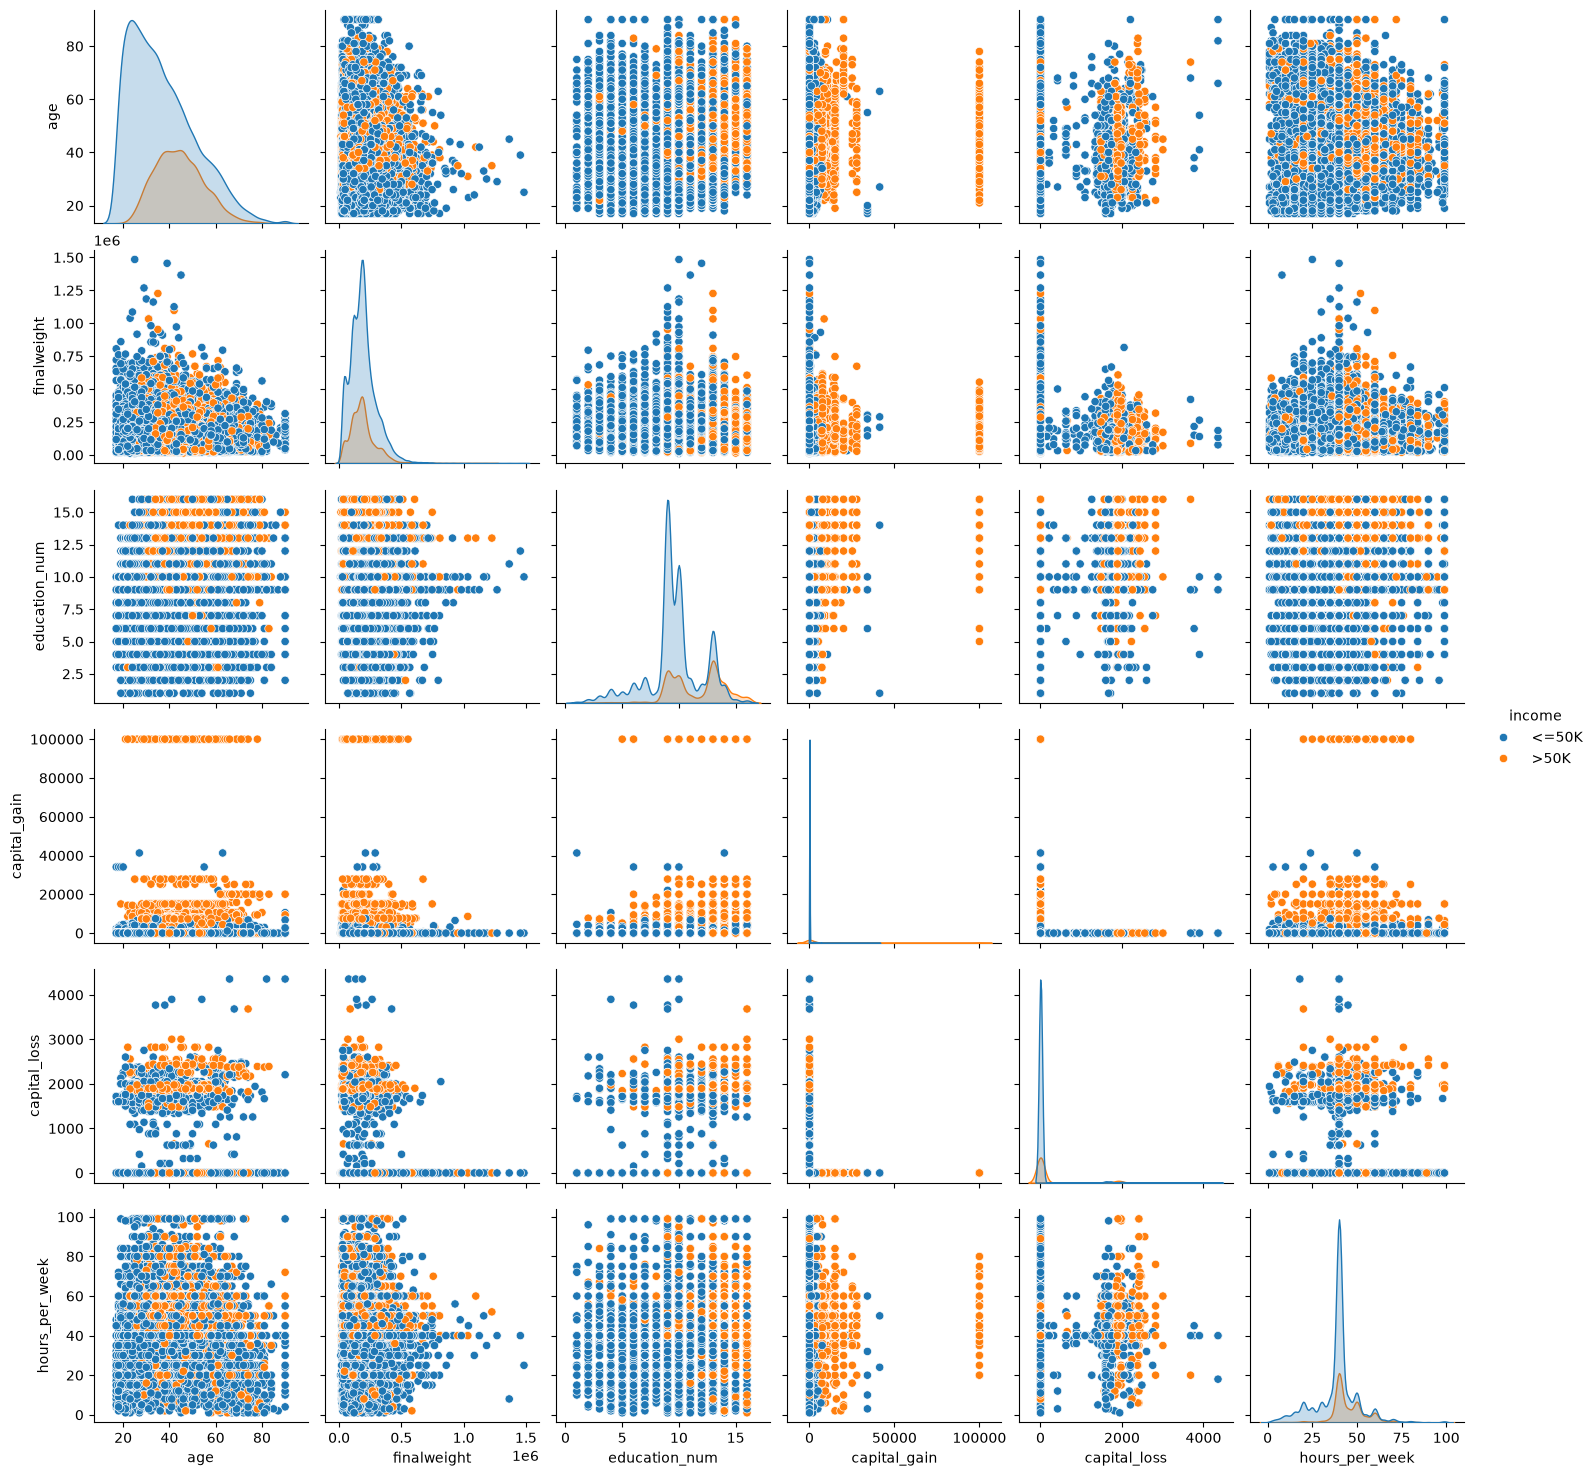

In [49]:
sns.pairplot(df,hue="income")
plt.show()

In [50]:
X = df.drop("income",axis=1)
y = df["income"]

In [51]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=0)

In [52]:
categorical = [col for col in X_train.columns if X_train[col].dtype == "str"]

In [53]:
X_train[categorical].isnull().sum()

workclass         1276
education            0
marital_status       0
occupation        1278
relationship         0
race                 0
sex                  0
native_country     414
dtype: int64

In [54]:
X_test[categorical].isnull().sum()

workclass         560
education           0
marital_status      0
occupation        565
relationship        0
race                0
sex                 0
native_country    169
dtype: int64

In [55]:
X_train["workclass"].mode()[0]

' Private'

In [56]:
for i in [X_train,X_test]:
    i["workclass"] =  i["workclass"].fillna(X_train["workclass"].mode()[0])
    i["occupation"] = i["occupation"] .fillna(X_train["occupation"].mode()[0])
    i["native_country"] =  i["native_country"].fillna(X_train["native_country"].mode()[0])

In [57]:
X_train[categorical].isnull().sum()

workclass         0
education         0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
native_country    0
dtype: int64

In [58]:
X_test[categorical].isnull().sum()

workclass         0
education         0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
native_country    0
dtype: int64

In [59]:
#encoding

In [60]:
X_train[categorical].head()

,workclass,education,marital_status,occupation,relationship,race,sex,native_country
32098,Private,HS-grad,Married-civ-spouse,Craft-repair,Husband,White,Male,United-States
25206,State-gov,HS-grad,Divorced,Adm-clerical,Unmarried,White,Female,United-States
23491,Private,Some-college,Married-civ-spouse,Sales,Husband,White,Male,United-States
12367,Private,HS-grad,Never-married,Craft-repair,Not-in-family,White,Male,Guatemala
7054,Private,7th-8th,Never-married,Craft-repair,Not-in-family,White,Male,Germany


In [62]:
y_train_binary = y_train.apply(lambda x:1 if x.strip() == ">50K" else 0)

In [63]:
y_train_binary

32098    1
25206    0
23491    1
12367    0
7054     0
        ..
13123    1
19648    0
9845     0
10799    1
2732     0
Name: income, Length: 22792, dtype: int64

In [66]:
target_means = y_train_binary.groupby(X_train["native_country"]).mean()

In [70]:
X_train["native_country_encoded"] = X_train["native_country"].map(target_means)
X_train["native_country_encoded"] = X_train["native_country_encoded"].fillna(y_train_binary.mean())

X_test["native_country_encoded"] = X_test["native_country"].map(target_means)
X_test["native_country_encoded"] = X_test["native_country_encoded"].fillna(y_train_binary.mean())

In [71]:
X_train.head()

,age,workclass,finalweight,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,native_country_encoded
32098,45,Private,170871,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,7298,0,60,United-States,0.245722
25206,47,State-gov,108890,HS-grad,9,Divorced,Adm-clerical,Unmarried,White,Female,1831,0,38,United-States,0.245722
23491,48,Private,187505,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,0,0,50,United-States,0.245722
12367,29,Private,145592,HS-grad,9,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Guatemala,0.041667
7054,23,Private,203003,7th-8th,4,Never-married,Craft-repair,Not-in-family,White,Male,0,0,25,Germany,0.284091


In [72]:
X_train = X_train.drop("native_country",axis=1)
X_test = X_test.drop("native_country",axis=1)

In [73]:
categorical

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country']

In [75]:
one_hot_categories =[
 'workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex']

In [78]:
encoder = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore",sparse_output=False),one_hot_categories)
    ], remainder="passthrough"
)

In [79]:
X_train_enc = encoder.fit_transform(X_train)
X_test_enc = encoder.transform(X_test)

In [80]:
X_train_enc

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
        60.        ,  0.24572168],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        38.        ,  0.24572168],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        50.        ,  0.24572168],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        40.        ,  0.24572168],
       [ 0.        ,  1.        ,  0.        , ...,  0.        ,
        45.        ,  0.24572168],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        48.        ,  0.24572168]], shape=(22792, 65))

In [83]:
columns = encoder.get_feature_names_out()

In [84]:
X_train = pd.DataFrame(X_train_enc,columns=columns,index = X_train.index)
X_test = pd.DataFrame(X_test_enc,columns=columns,index = X_test.index)

In [85]:
X_train

,cat__workclass_ Federal-gov,cat__workclass_ Local-gov,cat__workclass_ Never-worked,cat__workclass_ Private,cat__workclass_ Self-emp-inc,cat__workclass_ Self-emp-not-inc,cat__workclass_ State-gov,cat__workclass_ Without-pay,cat__education_ 10th,cat__education_ 11th,...,cat__race_ White,cat__sex_ Female,cat__sex_ Male,remainder__age,remainder__finalweight,remainder__education_num,remainder__capital_gain,remainder__capital_loss,remainder__hours_per_week,remainder__native_country_encoded
32098,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,45.0,170871.0,9.0,7298.0,0.0,60.0,0.245722
25206,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,47.0,108890.0,9.0,1831.0,0.0,38.0,0.245722
23491,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,48.0,187505.0,10.0,0.0,0.0,50.0,0.245722
12367,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,29.0,145592.0,9.0,0.0,0.0,40.0,0.041667
7054,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,23.0,203003.0,4.0,0.0,0.0,25.0,0.284091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13123,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,43.0,33331.0,14.0,0.0,0.0,40.0,0.245722
19648,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,44.0,98466.0,6.0,0.0,0.0,35.0,0.245722
9845,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,23.0,45317.0,10.0,0.0,0.0,40.0,0.245722
10799,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,45.0,215862.0,16.0,7688.0,0.0,45.0,0.245722


In [86]:
cols = X_train.columns

In [88]:
scaler = RobustScaler()

In [89]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [90]:
X_train

array([[ 0. ,  0. ,  0. , ...,  0. ,  4. ,  0. ],
       [ 0. ,  0. ,  0. , ...,  0. , -0.4,  0. ],
       [ 0. ,  0. ,  0. , ...,  0. ,  2. ,  0. ],
       ...,
       [ 0. ,  0. ,  0. , ...,  0. ,  0. ,  0. ],
       [ 0. ,  1. ,  0. , ...,  0. ,  1. ,  0. ],
       [ 0. ,  0. ,  0. , ...,  0. ,  1.6,  0. ]], shape=(22792, 65))

In [91]:
#training

In [93]:
rfc = RandomForestClassifier(n_estimators=10,random_state=15)
rfc.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",15
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

In [94]:
y_pred = rfc.predict(X_test)

In [95]:
print("Accuracy Score: ",accuracy_score(y_test,y_pred))
print("Confusion Matrix: \n",confusion_matrix(y_test,y_pred))
print("Classification Report: ",classification_report(y_test,y_pred))

Accuracy Score:  0.8482956290306071
Confusion Matrix: 
 [[6890  517]
 [ 965 1397]]
Classification Report:                precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      7407
        >50K       0.73      0.59      0.65      2362

    accuracy                           0.85      9769
   macro avg       0.80      0.76      0.78      9769
weighted avg       0.84      0.85      0.84      9769



In [96]:
rfc = RandomForestClassifier(n_estimators=100,random_state=15)
rfc.fit(X_train,y_train)
y_pred = rfc.predict(X_test)
print("Accuracy Score: ",accuracy_score(y_test,y_pred))
print("Confusion Matrix: \n",confusion_matrix(y_test,y_pred))
print("Classification Report: ",classification_report(y_test,y_pred))

Accuracy Score:  0.8546422356433616
Confusion Matrix: 
 [[6876  531]
 [ 889 1473]]
Classification Report:                precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7407
        >50K       0.74      0.62      0.67      2362

    accuracy                           0.85      9769
   macro avg       0.81      0.78      0.79      9769
weighted avg       0.85      0.85      0.85      9769



In [97]:
rfc.feature_importances_

array([5.86948083e-03, 5.92819446e-03, 7.71834128e-06, 1.11420821e-02,
       5.47836912e-03, 9.02457989e-03, 4.95195918e-03, 7.28838079e-05,
       1.31307915e-03, 1.75381534e-03, 8.17073623e-04, 2.85750399e-04,
       3.48189224e-04, 1.53961167e-03, 1.07880408e-03, 2.45245699e-03,
       3.06014470e-03, 1.06418670e-02, 2.66503020e-03, 7.14724635e-03,
       8.08808365e-03, 3.28595484e-05, 3.96490471e-03, 5.95817121e-03,
       5.98807638e-03, 2.83499574e-04, 6.18572859e-02, 9.87836968e-04,
       2.63805782e-02, 1.68775100e-03, 1.68465381e-03, 5.59884649e-03,
       2.49965342e-05, 8.37416717e-03, 1.85324301e-02, 3.82127988e-03,
       3.13200568e-03, 4.42128356e-03, 7.54398637e-03, 9.77432120e-05,
       1.39922136e-02, 3.11460587e-03, 7.37494753e-03, 5.13377748e-03,
       5.19738937e-03, 4.48361418e-02, 8.70027923e-03, 1.41561414e-03,
       9.58657802e-03, 4.45130797e-03, 1.07991701e-02, 1.39402872e-03,
       3.35400019e-03, 4.99209219e-03, 8.01672855e-04, 7.03217008e-03,
      

In [108]:
feature_scores = pd.Series(
    rfc.feature_importances_,
    index=cols
).sort_values(ascending=False)

In [109]:
feature_scores.head(10)

remainder__finalweight                     0.160256
remainder__age                             0.148601
remainder__capital_gain                    0.095241
remainder__hours_per_week                  0.084614
remainder__education_num                   0.071047
cat__marital_status_ Married-civ-spouse    0.061857
cat__relationship_ Husband                 0.044836
remainder__capital_loss                    0.029587
cat__marital_status_ Never-married         0.026381
cat__occupation_ Exec-managerial           0.018532
dtype: float64

In [110]:
feature_scores.tail(10)


cat__education_ 12th                      0.000817
cat__race_ Other                          0.000802
cat__education_ 5th-6th                   0.000348
cat__education_ 1st-4th                   0.000286
cat__marital_status_ Married-AF-spouse    0.000283
cat__occupation_ Priv-house-serv          0.000098
cat__workclass_ Without-pay               0.000073
cat__education_ Preschool                 0.000033
cat__occupation_ Armed-Forces             0.000025
cat__workclass_ Never-worked              0.000008
dtype: float64

In [112]:
X_train = pd.DataFrame(X_train, columns=cols)
X_test = pd.DataFrame(X_test, columns=cols)
X_train = X_train.drop([
    "cat_workclass_Never-worked",
    "cat_occupation_Armed-Forces",
    "cat_education_Preschool",
    "cat_workclass_Without-pay",
    "cat_occupation_Priv-house-serv",
    "cat_marital_status_Married-AF-spouse",
    "cat_education_1st-4th",
    "cat_education_5th-6th",
    "cat_race_Other",
    "cat_education_12th"
], axis=1)

In [115]:
X_test = X_test.drop(["cat__workclass_ Never-worked", "cat__occupation_ Armed-Forces","cat__education_ Preschool",
                       "cat__workclass_ Without-pay", "cat__occupation_ Priv-house-serv", "cat__marital_status_ Married-AF-spouse",
                        "cat__education_ 1st-4th", "cat__education_ 5th-6th", "cat__race_ Other", "cat__education_ 12th"
                       ], axis=1)

KeyError: "['cat__workclass_ Never-worked', 'cat__occupation_ Armed-Forces', 'cat__education_ Preschool', 'cat__workclass_ Without-pay', 'cat__occupation_ Priv-house-serv', 'cat__marital_status_ Married-AF-spouse', 'cat__education_ 1st-4th', 'cat__education_ 5th-6th', 'cat__race_ Other', 'cat__education_ 12th'] not found in axis"

In [116]:
rfc = RandomForestClassifier(n_estimators=100,random_state=15)
rfc.fit(X_train,y_train)
y_pred = rfc.predict(X_test)
print("Accuracy Score: ",accuracy_score(y_test,y_pred))
print("Confusion Matrix: \n",confusion_matrix(y_test,y_pred))
print("Classification Report: ",classification_report(y_test,y_pred))

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- cat__education_ 12th
- cat__education_ 1st-4th
- cat__education_ 5th-6th
- cat__education_ Preschool
- cat__marital_status_ Married-AF-spouse
- ...


In [117]:
X_train = X_train.drop(["cat__workclass_ Never-worked", "cat__occupation_ Armed-Forces","cat__education_ Preschool",
                       "cat__workclass_ Without-pay", "cat__occupation_ Priv-house-serv", "cat__marital_status_ Married-AF-spouse",
                        "cat__education_ 1st-4th", "cat__education_ 5th-6th", "cat__race_ Other", "cat__education_ 12th"
                       ], axis=1)

In [120]:
X_test = X_test.drop([
    "cat_workclass_Never-worked",
    "cat_occupation_Armed-Forces",
    "cat_education_Preschool",
    "cat_workclass_Without-pay",
    "cat_occupation_Priv-house-serv",
    "cat_marital_status_Married-AF-spouse",
    "cat_education_1st-4th",
    "cat_education_5th-6th",
    "cat_race_Other",
    "cat_education_12th"
], axis=1)

KeyError: "['cat_workclass_Never-worked', 'cat_occupation_Armed-Forces', 'cat_education_Preschool', 'cat_workclass_Without-pay', 'cat_occupation_Priv-house-serv', 'cat_marital_status_Married-AF-spouse', 'cat_education_1st-4th', 'cat_education_5th-6th', 'cat_race_Other', 'cat_education_12th'] not found in axis"

In [121]:
X_test.columns

Index(['cat__workclass_ Federal-gov', 'cat__workclass_ Local-gov',
       'cat__workclass_ Private', 'cat__workclass_ Self-emp-inc',
       'cat__workclass_ Self-emp-not-inc', 'cat__workclass_ State-gov',
       'cat__education_ 10th', 'cat__education_ 11th',
       'cat__education_ 7th-8th', 'cat__education_ 9th',
       'cat__education_ Assoc-acdm', 'cat__education_ Assoc-voc',
       'cat__education_ Bachelors', 'cat__education_ Doctorate',
       'cat__education_ HS-grad', 'cat__education_ Masters',
       'cat__education_ Prof-school', 'cat__education_ Some-college',
       'cat__marital_status_ Divorced',
       'cat__marital_status_ Married-civ-spouse',
       'cat__marital_status_ Married-spouse-absent',
       'cat__marital_status_ Never-married', 'cat__marital_status_ Separated',
       'cat__marital_status_ Widowed', 'cat__occupation_ Adm-clerical',
       'cat__occupation_ Craft-repair', 'cat__occupation_ Exec-managerial',
       'cat__occupation_ Farming-fishing',
       '

In [122]:
X_test = X_test.drop([
    "cat__workclass_ Never-worked",
    "cat__occupation_ Armed-Forces",
    "cat__education_ Preschool",
    "cat__workclass_ Without-pay",
    "cat__occupation_ Priv-house-serv",
    "cat__marital_status_ Married-AF-spouse",
    "cat__education_ 1st-4th",
    "cat__education_ 5th-6th",
    "cat__race_ Other",
    "cat__education_ 12th"
], axis=1)

KeyError: "['cat__workclass_ Never-worked', 'cat__occupation_ Armed-Forces', 'cat__education_ Preschool', 'cat__workclass_ Without-pay', 'cat__occupation_ Priv-house-serv', 'cat__marital_status_ Married-AF-spouse', 'cat__education_ 1st-4th', 'cat__education_ 5th-6th', 'cat__race_ Other', 'cat__education_ 12th'] not found in axis"

In [123]:
rfc = RandomForestClassifier(n_estimators=100, random_state=15)
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)
print(f'Model accuracy score with default decision-trees : {accuracy_score(y_test, y_pred)}')

Model accuracy score with default decision-trees : 0.8540280479066434


In [124]:
#hyperparamater tuning

In [127]:
rf_params = {"max_depth": [5, 8, 15, None, 10],
             "max_features": ["sqrt","log2",5, 6,7,8, "auto"],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]}

In [138]:
rf_params_cv = {
    "cv" : [2,3,4,5,6,7,8,9,10]
}

In [128]:
rfc = RandomForestClassifier()

In [129]:
rscv = RandomizedSearchCV(estimator=rfc,param_distributions=rf_params,cv=3,n_jobs=-1)
rscv.fit(X_train,y_train)

/opt/anaconda3/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:489: FitFailedWarning: 
3 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.14/site-packages/sklearn/base.py", line 1393, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/opt/anaconda3/lib/python3.14/site-packages/sklearn/base.py", line 554, in _validate_params
  

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 8, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_split': [2, 8, ...], 'n_estimators': [100, 200, ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selec

In [130]:
y_pred = rscv.predict(X_test)
print("Accuracy Score: ",accuracy_score(y_test,y_pred))
print("Confusion Matrix: \n",confusion_matrix(y_test,y_pred))
print("Classification Report: ",classification_report(y_test,y_pred))

Accuracy Score:  0.8610912068789026
Confusion Matrix: 
 [[6928  479]
 [ 878 1484]]
Classification Report:                precision    recall  f1-score   support

       <=50K       0.89      0.94      0.91      7407
        >50K       0.76      0.63      0.69      2362

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.80      9769
weighted avg       0.86      0.86      0.86      9769



In [131]:
rscv.best_params_

{'n_estimators': 500,
 'min_samples_split': 20,
 'max_features': 'log2',
 'max_depth': None}

In [146]:
rscv = RandomizedSearchCV(estimator=rfc,param_distributions=rf_params,cv=5,n_jobs=-1)
rscv.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 8, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_split': [2, 8, ...], 'n_estimators': [100, 200, ...]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selec

In [145]:
y_pred = rscv.predict(X_test)
print("Accuracy Score: ",accuracy_score(y_test,y_pred))
print("Confusion Matrix: \n",confusion_matrix(y_test,y_pred))
print("Classification Report: ",classification_report(y_test,y_pred))

Accuracy Score:  0.8547446002661481
Confusion Matrix: 
 [[6857  550]
 [ 869 1493]]
Classification Report:                precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7407
        >50K       0.73      0.63      0.68      2362

    accuracy                           0.85      9769
   macro avg       0.81      0.78      0.79      9769
weighted avg       0.85      0.85      0.85      9769

